In [ ]:
# ===========================================
# 哈勃常数测量：宇宙学数据分析
# 使用Tonry 2003数据拟合哈勃定律 v = H₀ * d
# ===========================================

import numpy as np
import matplotlib.pyplot as plt

# 导入天文数据处理库
import astropy.io.ascii  # 用于读取天文数据表格
import astropy.units as u  # 物理单位处理
import astropy.constants as ac  # 物理常数

# 在Google Colab中上传数据文件
from google.colab import files
uploaded = files.upload()


Saving Tonry_2003.vot to Tonry_2003.vot


In [ ]:

# ===========================================
# 1. 数据加载和预处理
# ===========================================

# 读取VOTable格式的天文数据（包含星系距离和速度信息）
dat = astropy.io.ascii.read("Tonry_2003.vot")

# print(dat)

# 计算距离数据：
# col8是距离模数的对数形式，72.0是H₀的初始假设值（km/s/Mpc）
# 10**dat["col8"]将距离模数转换为线性尺度
distance = 10**dat["col8"] / 72.0 * u.mpc

# 计算距离误差（从col9中提取）
distance_error = (10**(dat["col8"] + dat["col9"]) - 10**dat["col8"]) / 72.0 * u.mpc
# 10**dat["col9"]
# A=11 B=10
# col8=10
# col9=1
# dis=10**col8=10**10
# err=10**11-10**10(√)
# err=10**1(X)

# 计算速度数据：col7是速度的对数形式
velocity = 10**dat["col7"] * u.km / u.s


  col1     col2    col3   col4    col5   ...  col7  col8  col9  col10    col11  
-------- ------- ------- ------ -------- ... ----- ----- ----- -------- --------
 SN1972E  314.84   30.08 0.0023    N5253 ... 2.839 2.399 0.033 204.9697 -31.6692
 SN1980N 240.161 -56.689 0.0056    N1316 ... 3.225  3.14 0.043  50.6753 -37.2074
 SN1981B  292.97  64.743 0.0072    N4536 ... 3.334 3.077 0.041 188.6233   2.1995
 SN1981D 240.161 -56.689 0.0056    N1316 ... 3.225 3.044 0.055  50.6753 -37.2074
 SN1986G 309.543  19.401 0.0027    N5128 ... 2.908  2.44 0.035 201.4028 -43.0316
 SN1988U   8.737 -81.227   0.31     Anon ... 4.968 5.096 0.072   3.5756 -30.4164
 SN1989B 241.991  64.403 0.0036    N3627 ... 3.033 2.844  0.03 170.0578  12.9718
 SN1990N 294.369  75.987 0.0044    N4639 ...  3.12 3.204 0.035 190.7367  13.2566
 SN1990O  37.654   28.36 0.0307 M+034403 ... 3.964 3.977 0.025 258.8999  16.3241
 SN1990T 341.503 -31.526   0.04   P63925 ... 4.079 4.101 0.042 299.7601 -56.2583
     ...     ...     ...    

/usr/local/lib/python3.12/dist-packages/astropy/io/ascii/html.py:91: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup("\n".join(lines))


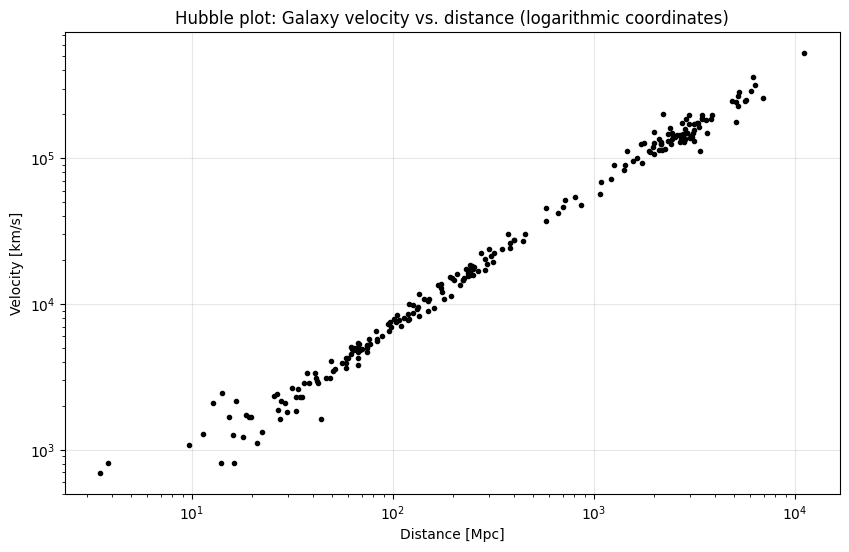

In [ ]:

# ===========================================
# 2. 数据可视化（对数坐标）
# 是因为线性坐标 近的地方数据比较密集 远的地方数据比较稀疏
# 拟合的时候可能会对近的拟合权重高 远的地方就考虑不到
# ===========================================

plt.figure(figsize=(10, 6))
# 绘制速度-距离关系的散点图（对数坐标）
plt.plot(distance.to(u.mpc).value, velocity.to(u.km / u.s).value,
         marker=".", color="black", linestyle="none")
plt.xscale("log")  # x轴使用对数坐标
plt.yscale("log")  # y轴使用对数坐标
plt.xlabel("Distance [Mpc]")
plt.ylabel("Velocity [km/s]")
plt.title("Hubble plot: Galaxy velocity vs. distance (logarithmic coordinates)")
plt.grid(True, alpha=0.3)
plt.show()


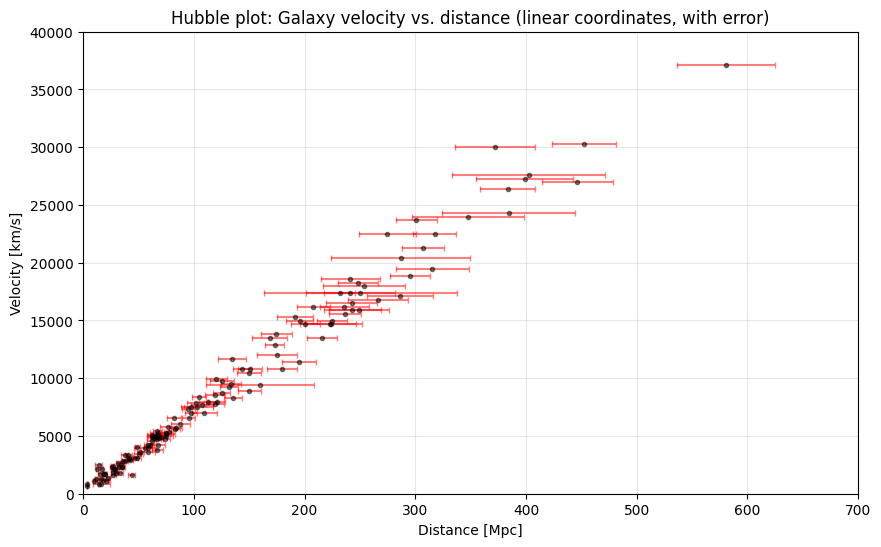

In [ ]:

# ===========================================
# 3. 数据可视化（线性坐标，带误差条）
# 为了和对数坐标对比
# ===========================================

plt.figure(figsize=(10, 6))
# 绘制带误差条的散点图
plt.errorbar(distance.to(u.mpc).value, velocity.to(u.km / u.s).value,
             xerr=distance_error.to(u.mpc).value,  # 距离误差
             marker=".", color="black", linestyle="none",
             ecolor='red', alpha=0.5, capsize=2)
plt.xlim(0, 700)  # 限制x轴范围
plt.ylim(0, 4e4)  # 限制y轴范围
plt.xlabel("Distance [Mpc]")
plt.ylabel("Velocity [km/s]")
plt.title("Hubble plot: Galaxy velocity vs. distance (linear coordinates, with error)")
plt.grid(True, alpha=0.3)
plt.show()


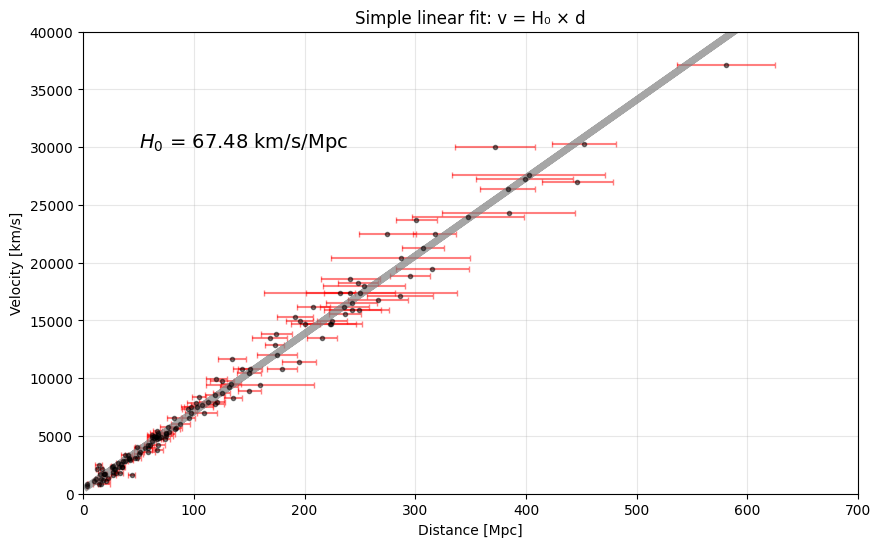

In [ ]:

# ===========================================
# 4. 简单线性拟合（最小二乘法）
# ===========================================

# 提取数据值（转换为numpy数组）
x = distance.to(u.mpc).value  # 距离（Mpc）
y = velocity.to(u.km / u.s).value  # 速度（km/s）

# 选择距离在0-700 Mpc范围内的数据点
ind = np.where((x > 0) & (x < 700))

# 使用numpy的polyfit进行线性拟合（v = H₀ * d）
# 返回的z = [斜率H₀, 截距]
z = np.polyfit(x[ind], y[ind], 1)

# 创建多项式函数对象（方便后续计算）
p = np.poly1d(z)

# 计算模型预测值
velocity_model = p(x[ind])

# 可视化拟合结果
plt.figure(figsize=(10, 6))
plt.errorbar(x[ind], y[ind],
             xerr=distance_error.to(u.mpc).value[ind],
             marker=".", color="black", linestyle="none",
             ecolor='red', alpha=0.5, capsize=2)
plt.plot(x[ind], velocity_model, color="grey", linewidth=5, alpha=0.7)
plt.xlim(0, 700)
plt.ylim(0, 4e4)
plt.xlabel("Distance [Mpc]")
plt.ylabel("Velocity [km/s]")
plt.title("Simple linear fit: v = H₀ × d")
plt.grid(True, alpha=0.3)

# 在图上标注哈勃常数估计值
plt.annotate(r"$H_0$ = {0:5.2f} km/s/Mpc".format(z[0]),
             xy=(50, 30000), fontsize=14)
plt.show()


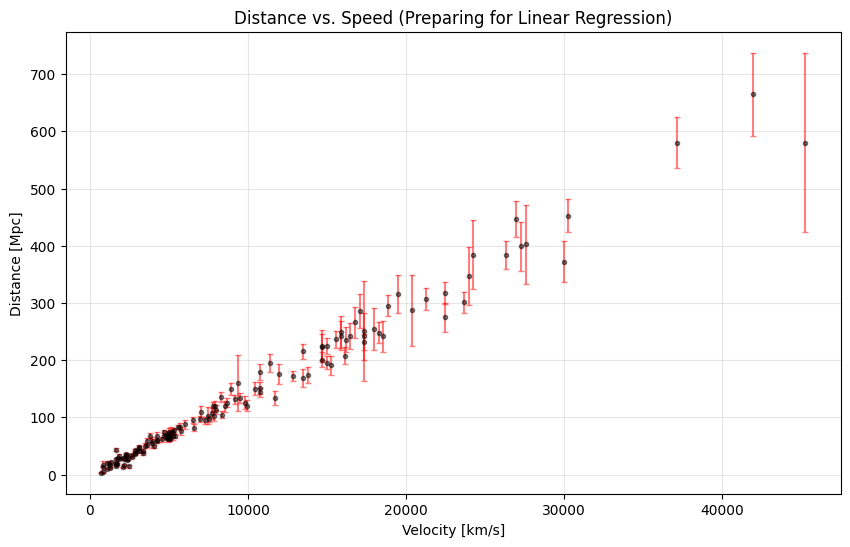

In [ ]:

# ===========================================
# 5. 交换坐标轴（以距离为因变量）
# 在宇宙学中，通常将距离视为速度的函数
# 距离是由La超新星的光度和固有光度做对比来间接计算距离 但是这个光度测量误差很大 这个方法有误差
# La超新星的光到我们观测点之间有星际尘埃 可能会导致误判
# 速度就是用光谱来测量 精确度很高
# ===========================================

x_new = y[ind]  # 速度作为自变量
y_new = x[ind]  # 距离作为因变量
yerr_new = distance_error.to(u.mpc).value[ind]  # 距离误差

plt.figure(figsize=(10, 6))
plt.errorbar(x_new, y_new, yerr=yerr_new,
             marker=".", color="black", linestyle="none",
             ecolor='red', alpha=0.5, capsize=2)
plt.ylabel("Distance [Mpc]")
plt.xlabel("Velocity [km/s]")
plt.title("Distance vs. Speed ​​(Preparing for Linear Regression)")
plt.grid(True, alpha=0.3)
plt.show()


加权最小二乘法结果：
斜率 m (即 1/H₀) = 0.014748 ± 0.000111
截距 b = -6.338 ± 0.219
哈勃常数 H₀ = 1/m = 67.80 ± 0.51 km/s/Mpc



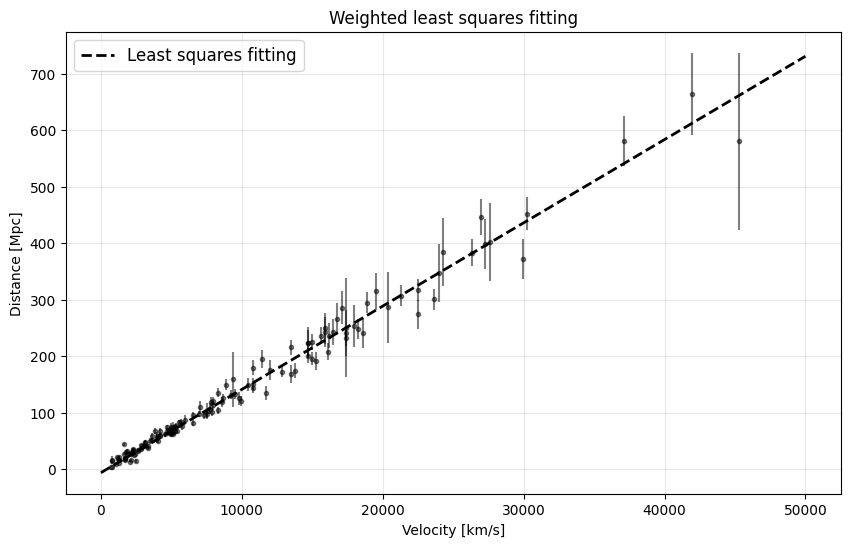

In [ ]:

# ===========================================
# 6. 矩阵形式的加权最小二乘法
# 这是传统的最小二乘回归方法
# 权重就是精确度
# ===========================================

# 创建Vandermonde矩阵（用于多项式拟合）
A = np.vander(x_new, 2)  # 生成[1, x]矩阵，用于拟合 d = m*v + b

# 创建协方差矩阵（对角矩阵，对角线元素为误差平方）
C = np.diag(yerr_new**2)

# 计算加权最小二乘的解：w = (AᵀWA)⁻¹ AᵀWy
# 其中W = C⁻¹
ATA = np.dot(A.T, A / (yerr_new**2)[:, None])
cov = np.linalg.inv(ATA)  # 参数协方差矩阵
w = np.linalg.solve(ATA, np.dot(A.T, y_new / yerr_new**2))

print("=" * 50)
print("加权最小二乘法结果：")
print("=" * 50)
print("斜率 m (即 1/H₀) = {0:.6f} ± {1:.6f}".format(w[0], np.sqrt(cov[0, 0])))
print("截距 b = {0:.3f} ± {1:.3f}".format(w[1], np.sqrt(cov[1, 1])))
print("哈勃常数 H₀ = 1/m = {0:.2f} ± {1:.2f} km/s/Mpc".format(
    1/w[0], np.sqrt(cov[0, 0])/w[0]**2))
print()

# 可视化最小二乘拟合结果
plt.figure(figsize=(10, 6))
plt.errorbar(x_new, y_new, yerr=yerr_new,
             fmt=".k", capsize=0, alpha=0.5)
x0 = np.linspace(0, 50000, 500)  # 生成用于绘制拟合线的速度值
plt.plot(x0, np.dot(np.vander(x0, 2), w), "--k",
         label="Least squares fitting", linewidth=2)
plt.ylabel("Distance [Mpc]")
plt.xlabel("Velocity [km/s]")
plt.title("Weighted least squares fitting")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# ==================================================
# 加权最小二乘法结果：
# ==================================================
# 斜率 m (即 1/H₀) = 0.014748 ± 0.000111
# 截距 b = -6.338 ± 0.219
# 哈勃常数 H₀ = 1/m = 67.80 ± 0.51 km/s/Mpc


In [ ]:

# ===========================================
# 7. 定义似然函数（最大似然估计）
# 考虑模型的不确定性（固有弥散）
# ===========================================

def log_likelihood(theta, x, y, yerr):
    """
    对数似然函数

    参数：
    theta = [m, b, log_f] - 拟合参数
      m: 斜率 (1/H₀)
      b: 截距
      log_f: 固有弥散的对数
    x: 速度数据
    y: 距离数据
    yerr: 距离测量误差

    返回：
    对数似然值
    """
    m, b, log_f = theta

    # 线性模型：d = m*v + b
    model = m * x + b

    # 总方差 = 测量误差² + (模型 × exp(log_f))²
    # exp(log_f) 是固有弥散的比例因子
    sigma2 = yerr**2 + model**2 * np.exp(2 * log_f)

    # 高斯似然函数：-0.5 * Σ[(y-model)²/sigma² + log(sigma²)]
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))


最大似然估计结果：
斜率 m (即 1/H₀) = 0.013964
截距 b = -0.981
固有弥散因子 f = 0.167
哈勃常数 H₀ = 1/m = 71.61 km/s/Mpc



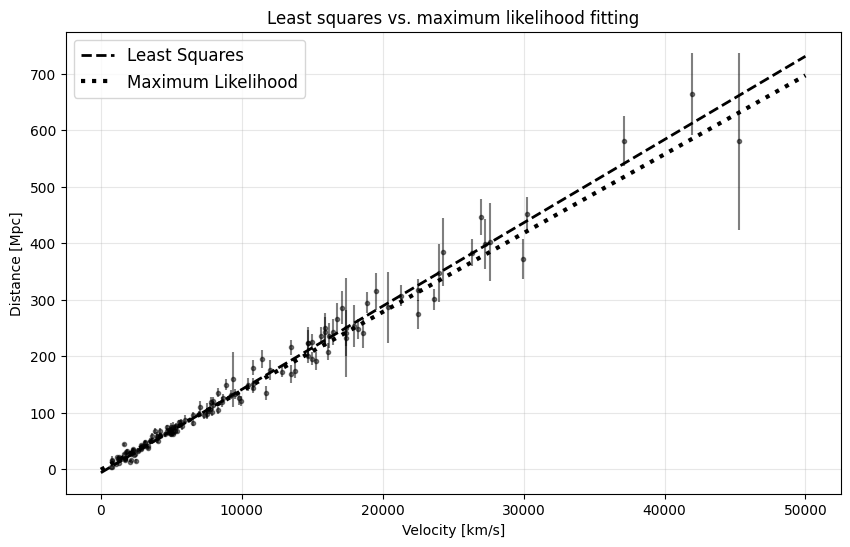

In [ ]:

# ===========================================
# 8. 最大似然估计（使用scipy优化）
# ===========================================

from scipy.optimize import minimize

# 设置随机种子以保证结果可重复
np.random.seed(42)

# 定义负对数似然函数（用于最小化）
nll = lambda *args: -log_likelihood(*args)

# 初始猜测值：
# m ≈ 1/72 ≈ 0.0139 (对应H₀≈72 km/s/Mpc)
# b ≈ 0
# log_f ≈ 0 (对应f≈1)
initial = np.array([1 / 72.0, 0.0, np.log(1.0)]) + 0.1 * np.random.randn(3)

# 使用数值优化找到最大似然估计
soln = minimize(nll, initial, args=(x_new, y_new, yerr_new))
m_ml, b_ml, log_f_ml = soln.x

print("=" * 50)
print("最大似然估计结果：")
print("=" * 50)
print("斜率 m (即 1/H₀) = {0:.6f}".format(m_ml))
print("截距 b = {0:.3f}".format(b_ml))
print("固有弥散因子 f = {0:.3f}".format(np.exp(log_f_ml)))
print("哈勃常数 H₀ = 1/m = {0:.2f} km/s/Mpc".format(1/m_ml))
print()

# 可视化最大似然拟合结果
plt.figure(figsize=(10, 6))
plt.errorbar(x_new, y_new, yerr=yerr_new,
             fmt=".k", capsize=0, alpha=0.5)
plt.plot(x0, np.dot(np.vander(x0, 2), w), "--k",
         label="Least Squares", linewidth=2)
plt.plot(x0, np.dot(np.vander(x0, 2), [m_ml, b_ml]), ":k",
         label="Maximum Likelihood", linewidth=3)
plt.ylabel("Distance [Mpc]")
plt.xlabel("Velocity [km/s]")
plt.title("Least squares vs. maximum likelihood fitting")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:

# ===========================================
# 9. 定义先验分布（贝叶斯分析）
# 感染新冠 阳性
# 阳性 1.没有感染 2.感染 后验
# 阴性 1.没有感染 2.感染

# 感染 1.阳性 2.阴性 先验
# ===========================================

def log_prior(theta):
    """
    对数先验函数

    参数：
    theta = [m, b, log_f]

    返回：
    先验概率的对数（无信息先验）
    """
    m, b, log_f = theta

    # 设定参数的合理范围：
    # m: 0.0到0.5 (对应H₀从2到无穷大)
    # b: -100到100 Mpc
    # log_f: -10到1 (对应f从4.5e-5到2.7)

    if 0.0 < m < 0.5 and -100.0 < b < 100.0 and -10.0 < log_f < 1.0:
        return 0.0  # 在范围内返回常数（均匀先验）
    return -np.inf  # 在范围外返回负无穷（概率为0）

def log_probability(theta, x, y, yerr):
    """
    对数后验概率（贝叶斯定理）

    后验 ∝ 先验 × 似然
    在对数空间中：log(后验) = log(先验) + log(似然)
    """
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)


In [ ]:

# ===========================================
# 10. 安装并使用emcee进行MCMC采样
# ===========================================

# 安装emcee库（在Colab中）
!pip install -U emcee

import emcee

# 设置MCMC的初始位置（以最大似然解为中心）
pos = soln.x + 1e-4 * np.random.randn(32, 3)  # 32个行走者，每个有3个参数
nwalkers, ndim = pos.shape

print("=" * 50)
print("开始MCMC采样...")
print("行走者数量:", nwalkers)
print("参数维度:", ndim)
print("=" * 50)

# 创建EnsembleSampler对象
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(x_new, y_new, yerr_new)
)

# 运行MCMC采样（5000步）
sampler.run_mcmc(pos, 5000, progress=True)

print("\nMCMC采样完成！")
print("总步数:", 5000)
print("总样本数:", nwalkers * 5000)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.8 MB/s eta 0:00:00
开始MCMC采样...
行走者数量: 32
参数维度: 3


100%|██████████| 5000/5000 [00:09<00:00, 544.90it/s]


MCMC采样完成！
总步数: 5000
总样本数: 160000


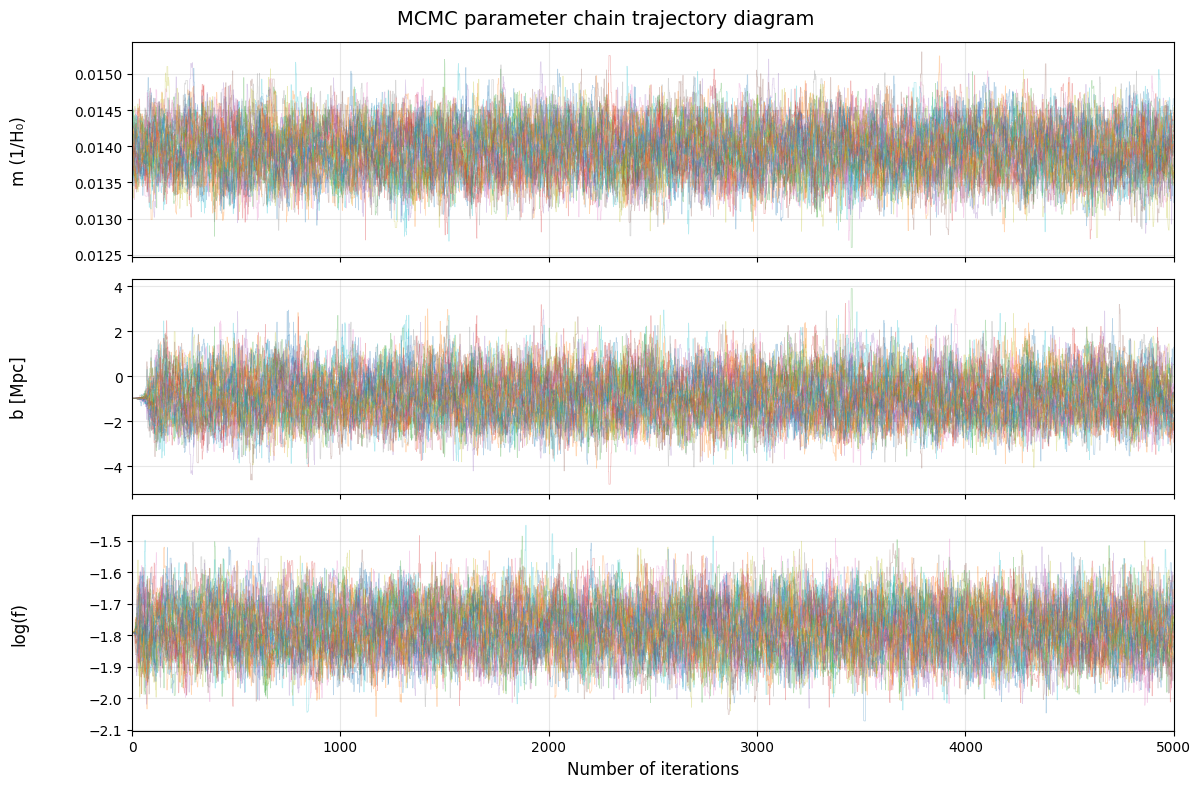

自相关时间（收敛性指标）：
m (1/H₀): 35.9 步
b [Mpc]: 37.3 步
log(f): 34.7 步

注：自相关时间越小，采样效率越高


In [ ]:

# ===========================================
# 11. 检查MCMC链的收敛性
# ===========================================

# 绘制参数链的轨迹图
fig, axes = plt.subplots(3, figsize=(12, 8), sharex=True)
samples = sampler.get_chain()  # 获取所有链
labels = ["m (1/H₀)", "b [Mpc]", "log(f)"]

for i in range(ndim):
    ax = axes[i]
    # 绘制每个行走者的链
    for j in range(nwalkers):
        ax.plot(samples[:, j, i], alpha=0.3, linewidth=0.5)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i], fontsize=12)
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Number of iterations", fontsize=12)
plt.suptitle("MCMC parameter chain trajectory diagram", fontsize=14)
plt.tight_layout()
plt.show()

# 计算自相关时间（评估链的收敛性）
tau = sampler.get_autocorr_time()
print("=" * 50)
print("自相关时间（收敛性指标）：")
print("=" * 50)
for i, label in enumerate(labels):
    print(f"{label}: {tau[i]:.1f} 步")
print("\n注：自相关时间越小，采样效率越高")


In [ ]:

# ===========================================
# 12. 处理MCMC样本（去除老化期，稀释样本）
# ===========================================
# 去除前100步作为老化期（burn-in），每15步取一个样本（稀释）
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
print(f"\n处理后样本形状: {flat_samples.shape}")
print(f"有效样本数: {flat_samples.shape[0]}")



处理后样本形状: (10432, 3)
有效样本数: 10432


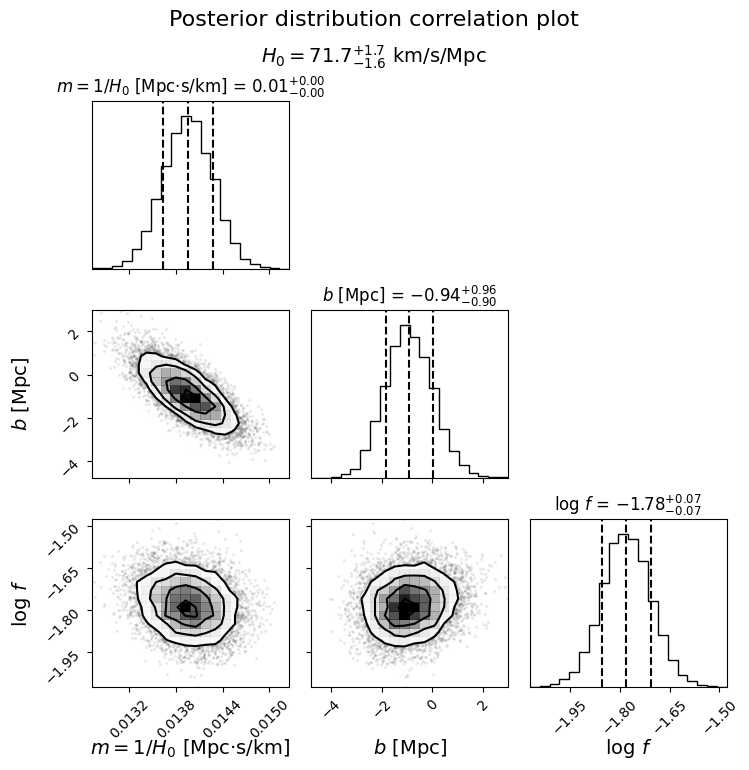

In [ ]:

# ===========================================
# 13. 绘制后验分布的相关图（corner plot）
# ===========================================

# 安装corner库
!pip install corner

import corner

fig = corner.corner(
    flat_samples,
    labels=[r"$m = 1/H_0$ [Mpc·s/km]",
            r"$b$ [Mpc]",
            r"$\log\,f$"],
    quantiles=[0.16, 0.5, 0.84],  # 显示16%, 50%, 84%分位数
    show_titles=True,
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 14}
)

# 在图上标注哈勃常数值
H0_samples = 1 / flat_samples[:, 0]  # 计算H₀ = 1/m
H0_median = np.median(H0_samples)
H0_lower = H0_median - np.percentile(H0_samples, 16)
H0_upper = np.percentile(H0_samples, 84) - H0_median

fig.text(0.5, 0.95,
         r"$H_0 = {:.1f}^{{+{:.1f}}}_{{-{:.1f}}}$ km/s/Mpc".format(
             H0_median, H0_upper, H0_lower),
         ha='center', fontsize=14)
plt.suptitle("Posterior distribution correlation plot", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


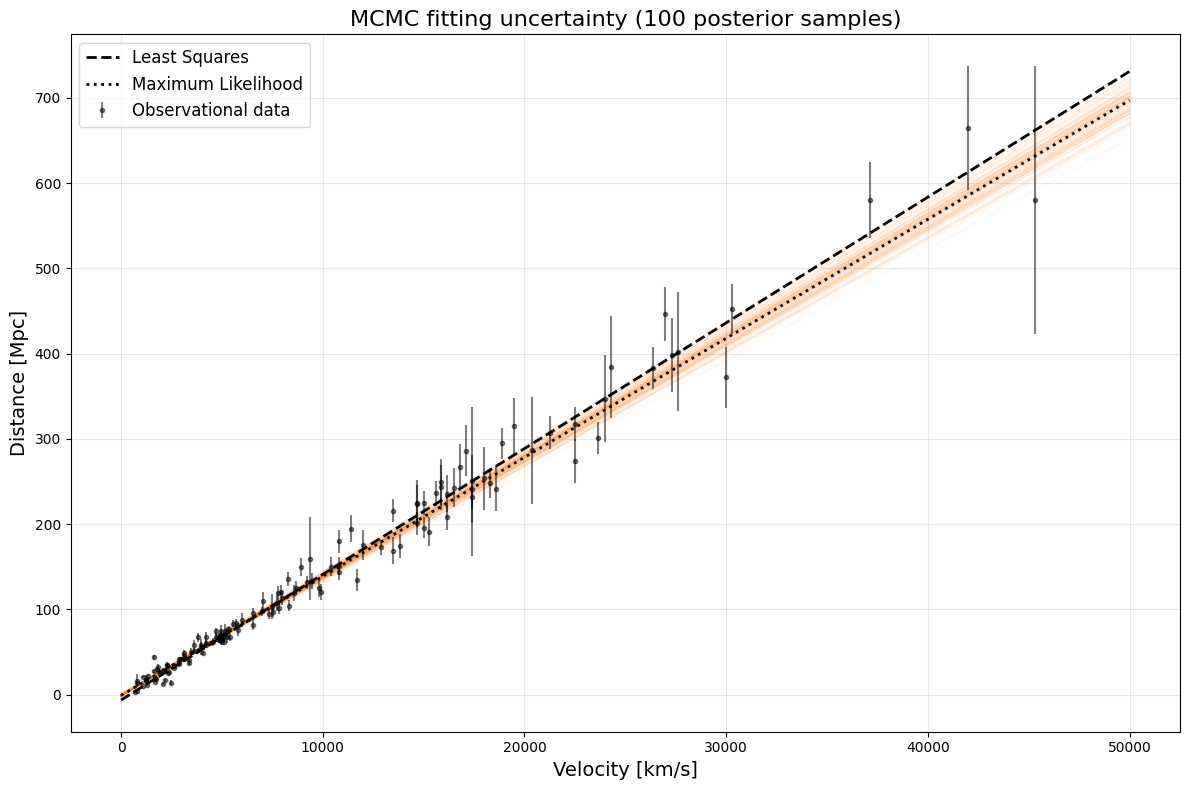

In [ ]:

# ===========================================
# 14. 可视化MCMC拟合的不确定性
# ===========================================

plt.figure(figsize=(12, 8))

# 从后验分布中随机抽取100个样本并绘制对应的拟合线
inds = np.random.randint(len(flat_samples), size=100)
for ind in inds:
    sample = flat_samples[ind]
    plt.plot(x0, np.dot(np.vander(x0, 2), sample[:2]),
             "C1", alpha=0.05, linewidth=1)

# 绘制数据点
plt.errorbar(x_new, y_new, yerr=yerr_new,
             fmt=".k", capsize=0, alpha=0.5, label="Observational data")

# 绘制最小二乘拟合
plt.plot(x0, np.dot(np.vander(x0, 2), w), "--k",
         label="Least Squares", linewidth=2)

# 绘制最大似然拟合
plt.plot(x0, np.dot(np.vander(x0, 2), [m_ml, b_ml]), ":k",
         label="Maximum Likelihood", linewidth=2)

plt.ylabel("Distance [Mpc]", fontsize=14)
plt.xlabel("Velocity [km/s]", fontsize=14)
plt.title("MCMC fitting uncertainty (100 posterior samples)", fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:

# ===========================================
# 15. 输出最终结果
# ===========================================

from IPython.display import display, Math

print("=" * 60)
print("哈勃常数测量最终结果（贝叶斯MCMC分析）")
print("=" * 60)
print()

# 对每个参数计算中位数和68%置信区间
for i in range(ndim):
    # 计算16%, 50%, 84%分位数
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)  # 计算上下误差

    # 创建LaTeX格式的输出
    if i == 0:  # 对于斜率m，额外计算H₀
        H0_median = 1 / mcmc[1]
        H0_upper = 1 / (mcmc[1] - q[0]) - H0_median
        H0_lower = H0_median - 1 / (mcmc[1] + q[1])

        txt1 = r"m = 1/H_0 = {0:.6f}_{{-{1:.6f}}}^{{+{2:.6f}}}".format(
            mcmc[1], q[0], q[1])
        txt2 = r"H_0 = {0:.2f}_{{-{1:.2f}}}^{{+{2:.2f}}} \ \mathrm{{km/s/Mpc}}".format(
            H0_median, H0_lower, H0_upper)

        display(Math(txt1))
        display(Math(txt2))
        print()
    else:
        txt = r"\mathrm{{{3}}} = {0:.5f}_{{-{1:.5f}}}^{{+{2:.5f}}}"
        txt = txt.format(mcmc[1], q[0], q[1], labels[i])
        display(Math(txt))
        print()

print("=" * 60)
print("分析完成！")
print("=" * 60)

哈勃常数测量最终结果（贝叶斯MCMC分析）



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


分析完成！
